<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/001_breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Classificação binária de tumores benignos e malignos com Machine Learning e Deep Learning

Este estudo utiliza o **Breast Cancer Wisconsin (Diagnostic)**, disponibilizado pelo **UCI Machine Learning Repository** por meio do pacote `ucimlrepo`.

O objetivo é construir e comparar duas abordagens para classificar tumores como **benignos (B)** ou **malignos (M)**:

1. **Regressão Logística**, utilizada como baseline;
2. **Rede Neural Multilayer Perceptron (MLP)**.

Além da acurácia, a avaliação considera **precision, recall, F1-score, ROC-AUC e matriz de confusão**.

> **Observação:** este notebook tem finalidade exclusivamente educacional e experimental. Ele não constitui ferramenta de diagnóstico clínico.


## 1. Configuração do ambiente

O pacote `ucimlrepo` é usado para obter o dataset diretamente do repositório UCI. As sementes aleatórias também são fixadas para tornar os resultados mais reproduzíveis entre execuções.


In [1]:
# Instala a biblioteca usada para acessar datasets do UCI Machine Learning Repository.
!pip -q install ucimlrepo

In [2]:
# Importações gerais.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset e pré-processamento.
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modelo baseline.
from sklearn.linear_model import LogisticRegression

# Métricas de avaliação.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)

# Rede neural.
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Exibição dos DataFrames.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

# Semente utilizada em todas as etapas aleatórias do estudo.
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Sempre que suportado pelo ambiente, solicita operações determinísticas no TensorFlow.
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

## 2. Carregamento do dataset

O dataset contém medições calculadas a partir de imagens digitalizadas de núcleos celulares. A variável-alvo é o diagnóstico:

- **B** — benigno;
- **M** — maligno.

As 30 variáveis preditoras são derivadas de características como raio, textura, perímetro, área, suavidade, compactação, concavidade, pontos côncavos, simetria e dimensão fractal.


In [3]:
# Carrega o Breast Cancer Wisconsin (Diagnostic), identificado como dataset 17 no UCI.
dataset = fetch_ucirepo(id=17)

# Separa as variáveis preditoras (X) e a variável-alvo original (y_raw).
X = dataset.data.features.copy()
y_raw = dataset.data.targets.squeeze().copy()

print(f"Número de amostras: {X.shape[0]}")
print(f"Número de atributos: {X.shape[1]}")
display(X.head())

Número de amostras: 569
Número de atributos: 30


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Exibe a distribuição original das classes.
class_distribution = y_raw.value_counts().rename_axis("Diagnóstico").to_frame("Quantidade")
class_distribution["Percentual (%)"] = (
    class_distribution["Quantidade"] / class_distribution["Quantidade"].sum() * 100
)

display(class_distribution.round(2))

,Quantidade,Percentual (%)
Diagnóstico,,
B,357,62.74
M,212,37.26


### Características do conjunto de dados

Para cada núcleo celular são consideradas dez características principais:

- raio;
- textura;
- perímetro;
- área;
- suavidade;
- compactação;
- concavidade;
- pontos côncavos;
- simetria;
- dimensão fractal.

Para essas características são calculadas estatísticas que resultam em **30 atributos numéricos** por amostra. O conjunto possui **569 registros**, sendo **357 benignos** e **212 malignos**, sem valores ausentes segundo a descrição do dataset.


## 3. Análise exploratória

Esta seção realiza uma inspeção inicial dos dados e identifica quais atributos apresentam maior correlação linear com o diagnóstico codificado.

A correlação não determina causalidade e não substitui uma análise clínica; aqui ela é usada apenas como ferramenta exploratória para entender a estrutura do conjunto de dados.


In [5]:
# Resume as principais estatísticas descritivas das variáveis numéricas.
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture1,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter1,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area1,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness1,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity1,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points1,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry1,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [6]:
# Codifica as classes: B = 0 e M = 1.
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapeamento das classes:", class_mapping)

Mapeamento das classes: {'B': np.int64(0), 'M': np.int64(1)}


In [7]:
# Calcula a correlação absoluta de cada atributo com o diagnóstico.
eda_df = X.copy()
eda_df["diagnosis"] = y

target_correlations = (
    eda_df.corr(numeric_only=True)["diagnosis"]
    .drop("diagnosis")
    .sort_values(key=np.abs, ascending=False)
)

display(target_correlations.head(10).to_frame("Correlação com o diagnóstico"))

,Correlação com o diagnóstico
concave_points3,0.793566
perimeter3,0.782914
concave_points1,0.776614
radius3,0.776454
perimeter1,0.742636
area3,0.733825
radius1,0.730029
area1,0.708984
concavity1,0.696360
concavity3,0.659610


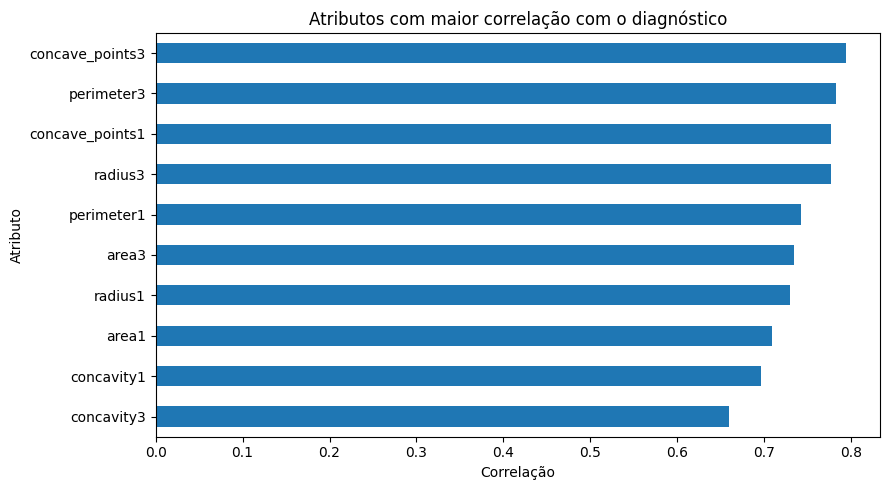

In [8]:
# Visualiza os dez atributos com maior correlação absoluta com o diagnóstico.
top_correlations = target_correlations.head(10).sort_values()

plt.figure(figsize=(9, 5))
top_correlations.plot(kind="barh")
plt.title("Atributos com maior correlação com o diagnóstico")
plt.xlabel("Correlação")
plt.ylabel("Atributo")
plt.tight_layout()
plt.show()

## 4. Separação entre treino, validação e teste

Para evitar que o conjunto de teste influencie o treinamento ou a escolha do modelo, os dados são divididos em três partes independentes:

- **70% — treino:** ajuste dos parâmetros dos modelos;
- **15% — validação:** acompanhamento do treinamento da rede neural;
- **15% — teste:** avaliação final.

A divisão é **estratificada**, preservando aproximadamente a proporção entre tumores benignos e malignos em cada subconjunto.


In [9]:
# Primeira divisão: 70% para treino e 30% para validação + teste.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)

# Segunda divisão: metade dos 30% vai para validação e metade para teste.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

split_summary = pd.DataFrame(
    {
        "Conjunto": ["Treino", "Validação", "Teste"],
        "Amostras": [len(y_train), len(y_val), len(y_test)],
        "Malignos": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    }
)
split_summary["Benignos"] = split_summary["Amostras"] - split_summary["Malignos"]

display(split_summary)

,Conjunto,Amostras,Malignos,Benignos
0,Treino,398,148,250
1,Validação,85,32,53
2,Teste,86,32,54


## 5. Padronização das variáveis

A rede neural e a Regressão Logística se beneficiam de atributos em escalas comparáveis.

Para evitar **data leakage**, o `StandardScaler` é ajustado **somente com os dados de treino**. Em seguida, a mesma transformação é aplicada aos conjuntos de validação e teste.


In [10]:
# Ajusta o scaler apenas no conjunto de treino.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 6. Modelo baseline — Regressão Logística

Antes de utilizar uma rede neural, é importante estabelecer um **baseline simples e interpretável**.

A Regressão Logística serve como referência para responder a uma pergunta importante: **a maior complexidade da rede neural produz uma melhora relevante neste problema?**


In [11]:
# Treina o modelo baseline com os dados padronizados.
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
)

baseline_model.fit(X_train_scaled, y_train)

# Predições finais do baseline no conjunto de teste.
baseline_predictions = baseline_model.predict(X_test_scaled)
baseline_probabilities = baseline_model.predict_proba(X_test_scaled)[:, 1]

## 7. Rede Neural Multilayer Perceptron

A arquitetura mantém a proposta central do experimento original, com três camadas densas ocultas e `Dropout` para regularização:

- 78 neurônios;
- 39 neurônios;
- 19 neurônios;
- saída sigmoide para classificação binária.

O treinamento utiliza `binary_crossentropy` e o otimizador Adam.


In [12]:
# Define a arquitetura da rede neural.
model = Sequential(
    [
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(78, activation="relu"),
        Dropout(0.20),
        Dense(39, activation="relu"),
        Dropout(0.20),
        Dense(19, activation="relu"),
        Dropout(0.20),
        Dense(1, activation="sigmoid"),
    ],
    name="breast_cancer_mlp",
)

# Compila o modelo para classificação binária.
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "breast_cancer_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 78)             │         2,418 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 39)             │         3,081 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 39)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 19)             │           760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,279 (24.53 KB)

 Trainable params: 6,279 (24.53 KB)

 Non-trainable params: 0 (0.00 B)

### Early Stopping

O treinamento pode ser interrompido quando a perda de validação deixa de melhorar. Isso reduz o risco de continuar treinando desnecessariamente e permite restaurar os melhores pesos encontrados durante o processo.


In [13]:
# Interrompe o treinamento se a perda de validação não melhorar por 15 épocas.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

# Treina a rede usando apenas o conjunto de validação para acompanhar generalização.
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
)

print(f"Épocas executadas: {len(history.history['loss'])}")

Épocas executadas: 30


## 8. Curvas de treinamento

As curvas de `loss` e `accuracy` permitem observar o comportamento do modelo nos conjuntos de treino e validação e ajudam a identificar sinais de sobreajuste.


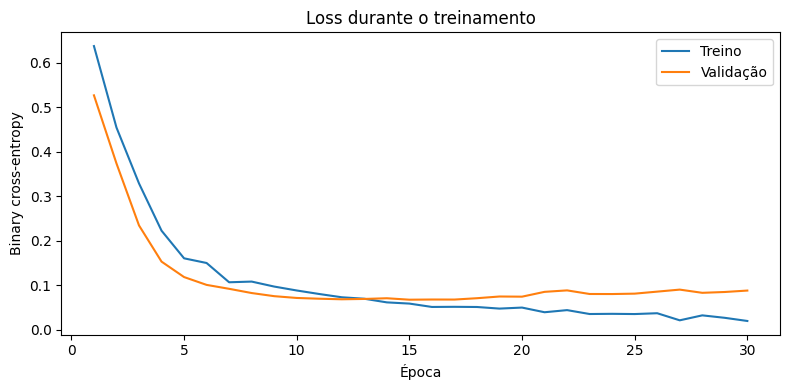

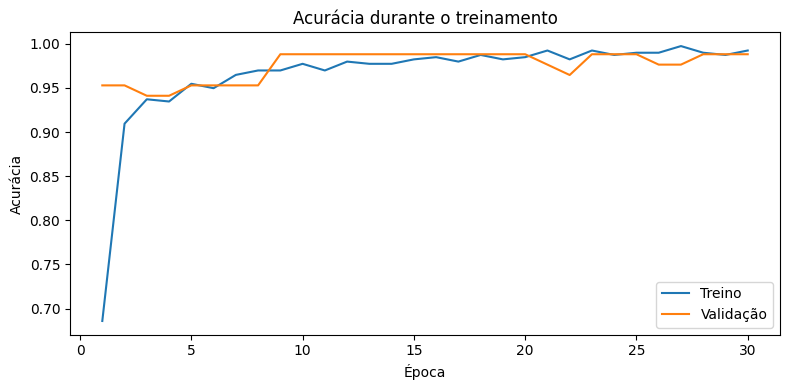

In [14]:
# Organiza o histórico de treinamento em um DataFrame.
history_df = pd.DataFrame(history.history)

# Curva de perda.
plt.figure(figsize=(8, 4))
plt.plot(history_df.index + 1, history_df["loss"], label="Treino")
plt.plot(history_df.index + 1, history_df["val_loss"], label="Validação")
plt.title("Loss durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Binary cross-entropy")
plt.legend()
plt.tight_layout()
plt.show()

# Curva de acurácia.
plt.figure(figsize=(8, 4))
plt.plot(history_df.index + 1, history_df["accuracy"], label="Treino")
plt.plot(history_df.index + 1, history_df["val_accuracy"], label="Validação")
plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Avaliação final

O conjunto de teste é utilizado somente nesta etapa. As métricas escolhidas são:

- **Accuracy:** proporção total de classificações corretas;
- **Precision:** proporção de previsões positivas que estavam corretas;
- **Recall:** proporção dos casos positivos corretamente identificados;
- **F1-score:** média harmônica entre precision e recall;
- **ROC-AUC:** capacidade de discriminação entre as duas classes em diferentes limiares.

Como **M (maligno)** foi codificado como classe positiva (`1`), precision, recall e F1 referem-se diretamente à identificação dessa classe.


In [15]:
# Gera probabilidades e classes previstas pela rede neural.
nn_probabilities = model.predict(X_test_scaled, verbose=0).ravel()
nn_predictions = (nn_probabilities >= 0.50).astype(int)

def calculate_metrics(y_true, y_pred, y_prob):
    """Calcula as principais métricas utilizadas neste estudo."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }

# Compara o baseline com a rede neural no mesmo conjunto de teste.
results = pd.DataFrame(
    {
        "Regressão Logística": calculate_metrics(
            y_test,
            baseline_predictions,
            baseline_probabilities,
        ),
        "Rede Neural MLP": calculate_metrics(
            y_test,
            nn_predictions,
            nn_probabilities,
        ),
    }
).T

display(results.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC
Regressão Logística,0.9767,0.9688,0.9688,0.9688,0.9988
Rede Neural MLP,0.9884,1.0000,0.9688,0.9841,1.0000


In [16]:
# Relatório detalhado da Regressão Logística.
print("REGRESSÃO LOGÍSTICA")
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=["Benigno", "Maligno"],
        digits=4,
    )
)

# Relatório detalhado da Rede Neural.
print("REDE NEURAL MLP")
print(
    classification_report(
        y_test,
        nn_predictions,
        target_names=["Benigno", "Maligno"],
        digits=4,
    )
)

REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

     Benigno     0.9815    0.9815    0.9815        54
     Maligno     0.9688    0.9688    0.9688        32

    accuracy                         0.9767        86
   macro avg     0.9751    0.9751    0.9751        86
weighted avg     0.9767    0.9767    0.9767        86

REDE NEURAL MLP
              precision    recall  f1-score   support

     Benigno     0.9818    1.0000    0.9908        54
     Maligno     1.0000    0.9688    0.9841        32

    accuracy                         0.9884        86
   macro avg     0.9909    0.9844    0.9875        86
weighted avg     0.9886    0.9884    0.9883        86



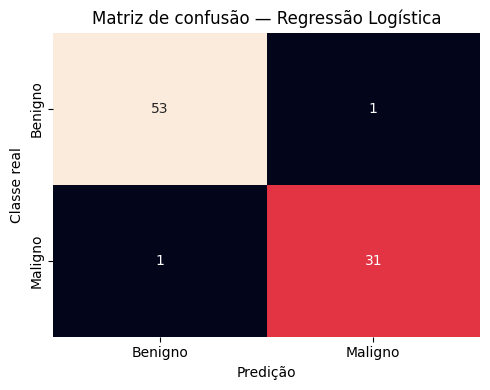

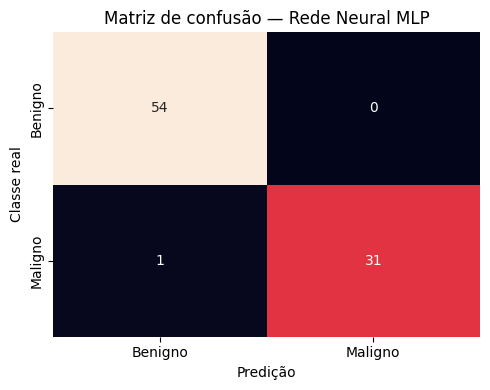

In [17]:
# Matriz de confusão da Regressão Logística.
baseline_cm = confusion_matrix(y_test, baseline_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
)
plt.title("Matriz de confusão — Regressão Logística")
plt.xlabel("Predição")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

# Matriz de confusão da Rede Neural.
nn_cm = confusion_matrix(y_test, nn_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    nn_cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
)
plt.title("Matriz de confusão — Rede Neural MLP")
plt.xlabel("Predição")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

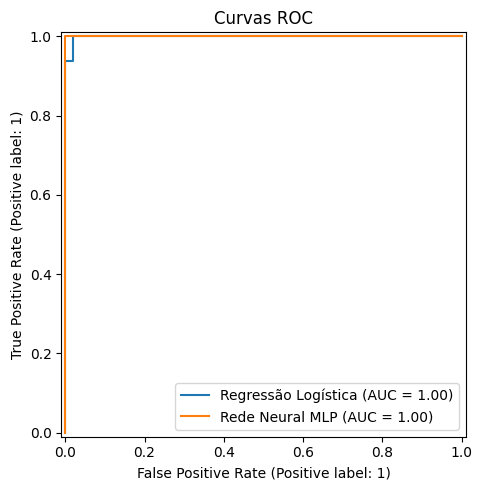

In [18]:
# Compara as curvas ROC dos dois modelos.
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    baseline_probabilities,
    name="Regressão Logística",
    ax=ax,
)

RocCurveDisplay.from_predictions(
    y_test,
    nn_probabilities,
    name="Rede Neural MLP",
    ax=ax,
)

ax.set_title("Curvas ROC")
fig.tight_layout()
plt.show()

## 10. Conclusão

A célula abaixo gera automaticamente uma síntese com as métricas obtidas na execução atual. Isso evita registrar no texto valores de uma execução anterior e mantém a conclusão consistente com o resultado efetivamente reproduzido no notebook.


In [19]:
# Gera uma conclusão baseada nos resultados efetivamente obtidos nesta execução.
from IPython.display import Markdown, display

baseline = results.loc["Regressão Logística"]
mlp = results.loc["Rede Neural MLP"]

best_f1_model = results["F1"].idxmax()
best_auc_model = results["ROC-AUC"].idxmax()

conclusion = f"""
### Síntese dos resultados

Neste experimento, a **Regressão Logística** alcançou:

- **Accuracy:** {baseline['Accuracy']:.4f}
- **Precision:** {baseline['Precision']:.4f}
- **Recall:** {baseline['Recall']:.4f}
- **F1-score:** {baseline['F1']:.4f}
- **ROC-AUC:** {baseline['ROC-AUC']:.4f}

A **Rede Neural MLP** alcançou:

- **Accuracy:** {mlp['Accuracy']:.4f}
- **Precision:** {mlp['Precision']:.4f}
- **Recall:** {mlp['Recall']:.4f}
- **F1-score:** {mlp['F1']:.4f}
- **ROC-AUC:** {mlp['ROC-AUC']:.4f}

O melhor **F1-score** foi obtido por **{best_f1_model}**, enquanto o melhor **ROC-AUC** foi obtido por **{best_auc_model}**.

Os resultados mostram que é importante comparar a rede neural com um modelo mais simples antes de concluir que uma arquitetura mais complexa é necessária. Em um conjunto relativamente pequeno como este, diferenças modestas entre os modelos devem ser interpretadas com cautela.

A separação independente entre **treino, validação e teste** torna a avaliação mais rigorosa do que na versão inicial do experimento, pois o conjunto de teste não participa do treinamento nem do acompanhamento das épocas.

### Limitações

- O dataset possui apenas **569 amostras**.
- O resultado depende de uma única divisão estratificada dos dados.
- Não foi realizada validação cruzada.
- Não houve otimização sistemática de hiperparâmetros.
- O desempenho foi avaliado no próprio dataset de referência, sem validação externa.
- O estudo tem finalidade educacional e **não deve ser interpretado como validação clínica de um sistema diagnóstico**.

### Próximos passos

Como continuidade do estudo, seria interessante:

1. comparar outros modelos, como **SVM, Random Forest e Gradient Boosting/XGBoost**;
2. aplicar **validação cruzada estratificada**;
3. avaliar a estabilidade das métricas em diferentes sementes aleatórias;
4. realizar otimização de hiperparâmetros;
5. investigar explicabilidade das previsões;
6. analisar com mais detalhe os falsos positivos e falsos negativos;
7. testar o desempenho em dados externos, quando disponíveis.
"""

display(Markdown(conclusion))


### Síntese dos resultados

Neste experimento, a **Regressão Logística** alcançou:

- **Accuracy:** 0.9767
- **Precision:** 0.9688
- **Recall:** 0.9688
- **F1-score:** 0.9688
- **ROC-AUC:** 0.9988

A **Rede Neural MLP** alcançou:

- **Accuracy:** 0.9884
- **Precision:** 1.0000
- **Recall:** 0.9688
- **F1-score:** 0.9841
- **ROC-AUC:** 1.0000

O melhor **F1-score** foi obtido por **Rede Neural MLP**, enquanto o melhor **ROC-AUC** foi obtido por **Rede Neural MLP**.

Os resultados mostram que é importante comparar a rede neural com um modelo mais simples antes de concluir que uma arquitetura mais complexa é necessária. Em um conjunto relativamente pequeno como este, diferenças modestas entre os modelos devem ser interpretadas com cautela.

A separação independente entre **treino, validação e teste** torna a avaliação mais rigorosa do que na versão inicial do experimento, pois o conjunto de teste não participa do treinamento nem do acompanhamento das épocas.

### Limitações

- O dataset possui apenas **569 amostras**.
- O resultado depende de uma única divisão estratificada dos dados.
- Não foi realizada validação cruzada.
- Não houve otimização sistemática de hiperparâmetros.
- O desempenho foi avaliado no próprio dataset de referência, sem validação externa.
- O estudo tem finalidade educacional e **não deve ser interpretado como validação clínica de um sistema diagnóstico**.

### Próximos passos

Como continuidade do estudo, seria interessante:

1. comparar outros modelos, como **SVM, Random Forest e Gradient Boosting/XGBoost**;
2. aplicar **validação cruzada estratificada**;
3. avaliar a estabilidade das métricas em diferentes sementes aleatórias;
4. realizar otimização de hiperparâmetros;
5. investigar explicabilidade das previsões;
6. analisar com mais detalhe os falsos positivos e falsos negativos;
7. testar o desempenho em dados externos, quando disponíveis.
